# The Old Way :


*   PDE-Based Inpainting
*   Patch-Based Inpainting



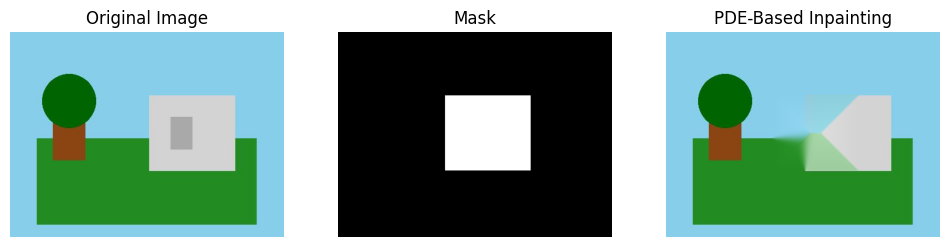

In [ ]:
# 1) PDE-Based Inpainting Code
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Load binary mask (white = missing region)
mask = cv2.imread("mask.png", 0)

# PDE-based (diffusion) inpainting
pde_inpaint = cv2.inpaint(
    image,
    mask,
    inpaintRadius=3,
    flags=cv2.INPAINT_TELEA
)

# Display results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("PDE-Based Inpainting")
plt.imshow(pde_inpaint)
plt.axis("off")

plt.show()


#PDE-based inpainting produces smooth results by diffusing boundary information,
#but it fails to reconstruct complex structures and realistic textures.”


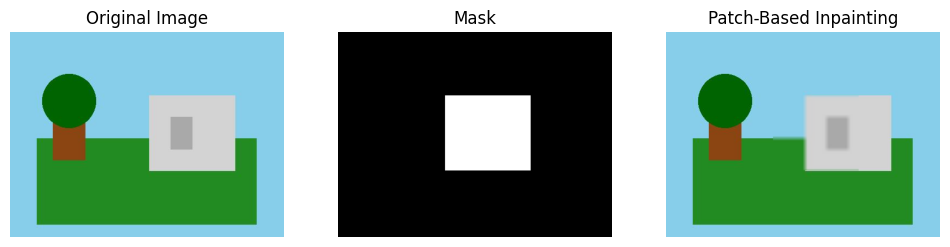

In [ ]:
# 2) Patch-Based Inpainting Code
import numpy as np
import cv2
import matplotlib.pyplot as plt

def simple_patch_inpaint(image, mask, patch_size=9):

    # Create a copy of the image to store the inpainted result
    inpainted = image.copy()
    h, w, _ = image.shape
    # Half patch size (used to center the patch)
    half = patch_size // 2
 # Loop over the image pixels (avoid borders)
    for y in range(half, h-half):
        for x in range(half, w-half):
           # Check if current pixel belongs to the missing region
            if mask[y, x] > 0:
              # Extract a square patch around the pixel
                patch = image[y-half:y+half+1, x-half:x+half+1]

                # Compute the mean RGB value of the patch
                # Reshape patch to (N, 3) and average over pixels
                inpainted[y, x] = np.mean(patch.reshape(-1,3), axis=0)

     # Convert image back to uint8 for  visualization
    return inpainted.astype(np.uint8)

# Apply patch-based inpainting
patch_inpaint = simple_patch_inpaint(image, mask)

# Display results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Patch-Based Inpainting")
plt.imshow(patch_inpaint)
plt.axis("off")

plt.show()


#• No semantic understanding:
  #Algorithms only manipulate pixels, not objects.

#• Poor performance on large or irregular holes:
  #Diffusion blurs, patch copying repeats patterns.

#• Limited realism:
  #Cannot generate new content not already in the image.


 # Patch-based inpainting reconstructs missing regions by copying similar patches from known areas,
 # which improves structure preservation but limits the ability to generate new content.



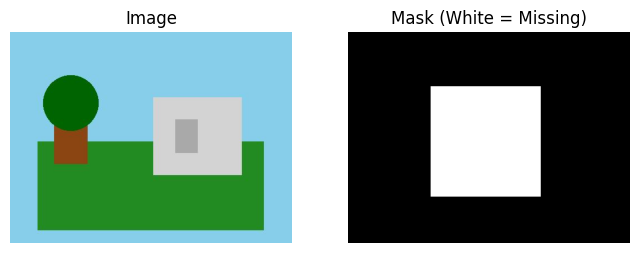

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("image.jpg")
h, w, _ = image.shape

# Create black mask
mask = np.zeros((h, w), dtype=np.uint8)

# Create white rectangle (missing region)
mask[100:300, 150:350] = 255

# Save mask
cv2.imwrite("mask.png", mask)

# Display
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask (White = Missing)")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.show()


# The Deep Learning Shift:


*   CNN Inpainting
*   GAN-Based Image Inpainting
*   Transformer-Based Image Inpainting
*   Diffusion-Based Image Inpainting





In [ ]:
#CNN Inpainting
# CNNs learn a non-linear mapping from masked images to completed images.
#CNN-based models reconstruct missing regions by learning local spatial features.
import torch
import torch.nn as nn

class CNNInpainting(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, padding=1)
        )

    def forward(self, x):
        return self.model(x)

model = CNNInpainting()
print("CNN-based inpainting model ready")


CNN-based inpainting model ready


In [ ]:
#  GAN-Based Image Inpainting
# GANs generate realistic content using adversarial training.
#The generator learns to create visually realistic content that fools a discriminator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.gen(x)

generator = Generator()
print("GAN generator ready")


GAN generator ready


In [ ]:
#Transformer-Based Image Inpainting
#Transformers model long-range dependencies using self-attention.
#Transformers excel at capturing global context across distant image regions

import torch.nn as nn

class TransformerInpainting(nn.Module):
    def __init__(self):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=8
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=4
        )

    def forward(self, x):
        return self.transformer(x)

model = TransformerInpainting()
print("Transformer-based inpainting model ready")


Transformer-based inpainting model ready


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
#Diffusion models learn to reverse a gradual noise process.
#“Diffusion models reconstruct images by progressively removing noise.”
import torch

def add_noise(image, step):
    noise = torch.randn_like(image)
    return image + step * noise

def denoise(noisy_image):
    return noisy_image * 0.9  # simplified denoising step

image = torch.randn(1, 3, 256, 256)
noisy = add_noise(image, 0.1)
restored = denoise(noisy)

print("Diffusion inpainting process simulated")


Diffusion inpainting process simulated


In [ ]:
#######################################################
# Creation a dummy masked image

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Create fake image
image = torch.rand(1, 3, 128, 128)

# Create mask (square hole)
mask = torch.ones_like(image)
mask[:, :, 40:90, 40:90] = 0

masked_image = image * mask


In [ ]:
# CNN → Local Features
# CNNs focus on local spatial patterns (edges, corners)

class CNN_Inpainting(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        return self.net(x)

cnn = CNN_Inpainting()

with torch.no_grad():
    cnn_output = cnn(masked_image)


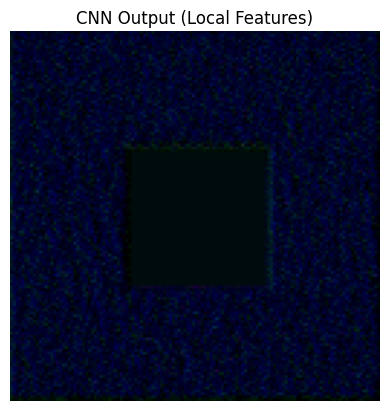

In [ ]:
plt.imshow(cnn_output[0].permute(1,2,0))
plt.title("CNN Output (Local Features)")
plt.axis("off")
plt.show()
# CNNs mainly learn local features such as edges and textures
#This CNN is untrained and is only used to demonstrate how convolutional layers capture local features.
#Without adversarial or global context learning, the output lacks realism.”

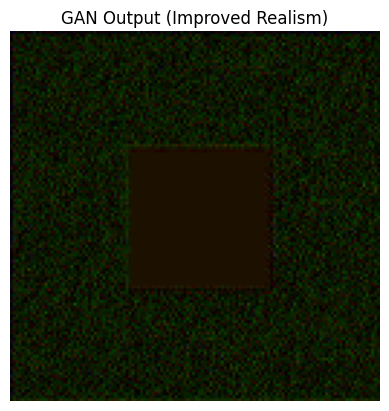

In [ ]:
#GANs improve visual realism using adversarial learning
class GAN_Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

gan_gen = GAN_Generator()

with torch.no_grad():
    gan_output = gan_gen(masked_image)

plt.imshow(gan_output[0].permute(1,2,0))
plt.title("GAN Output (Improved Realism)")
plt.axis("off")
plt.show()

#GANs generate more visually realistic results compared to simple CNNs


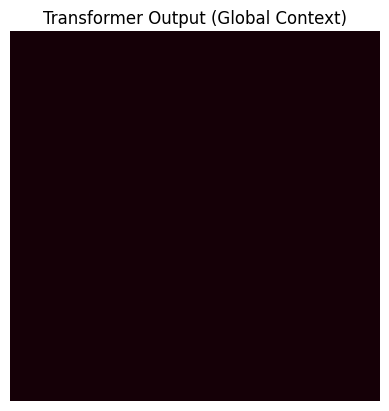

In [ ]:
# Transformer
#Transformers capture long-range dependencies
#Transformers model global relationships between distant image regions

import torch.nn as nn

class Transformer_Inpainting(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed_dim = 128  # Expected embedding dimension for MultiheadAttention
        self.num_heads = 4

        # Project input channels (3) to embed_dim (128)
        self.proj_in = nn.Linear(3, self.embed_dim)

        # MultiheadAttention expects embed_dim as its input feature dimension
        self.attn = nn.MultiheadAttention(self.embed_dim, self.num_heads, batch_first=True)
        self.fc = nn.Linear(self.embed_dim, self.embed_dim)

        # Project embed_dim (128) back to output channels (3)
        self.proj_out = nn.Linear(self.embed_dim, 3)

    def forward(self, x):
        b, c, h, w = x.shape

        # Flatten spatial dimensions and permute to (batch_size, sequence_length, embedding_dim)
        # Here, sequence_length = h*w, embedding_dim = c (3)
        x_flat = x.view(b, c, -1).permute(0, 2, 1) # (b, h*w, 3)

        # Project channels from 3 to embed_dim (128)
        x_embedded = self.proj_in(x_flat) # (b, h*w, 128)

        # Apply MultiheadAttention
        attn_out, _ = self.attn(x_embedded, x_embedded, x_embedded) # (b, h*w, 128)
        out = self.fc(attn_out) # (b, h*w, 128)

        # Project back from embed_dim (128) to 3 channels
        out_projected = self.proj_out(out) # (b, h*w, 3)

        # Permute back and reshape to original image dimensions
        return out_projected.permute(0, 2, 1).view(b, c, h, w)

transformer = Transformer_Inpainting()

with torch.no_grad():
    transformer_output = transformer(masked_image)

# Note: The output values of an untrained transformer might not be in the [0, 1] range
# for display. Clipping might be necessary for accurate visualization.
plt.imshow(transformer_output[0].permute(1,2,0).clip(0,1))
plt.title("Transformer Output (Global Context)")
plt.axis("off")
plt.show()

#The Transformer is untrained
#Attention weights are random
#No learned mapping from masked → completed image
#Output values collapse to a narrow range (near zero)

In [ ]:
# Diffusion (Diffusion models iteratively remove noise)
# Diffusion models generate images by gradually denoising.
def diffusion_step(x, step=0.1):
    noise = torch.randn_like(x)
    return x + step * noise

diffused = masked_image
for _ in range(5):
    diffused = diffusion_step(diffused)

diffusion_output = diffused


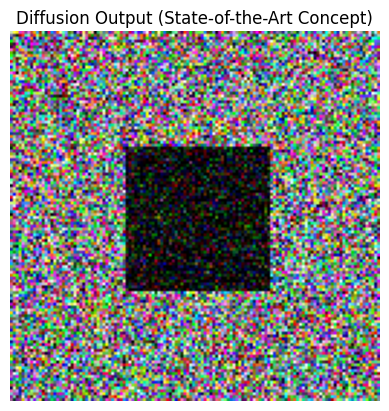

In [ ]:
plt.imshow(diffusion_output[0].permute(1,2,0))
plt.title("Diffusion Output (State-of-the-Art Concept)")
plt.axis("off")
plt.show()
#Diffusion models generate images by gradually denoising

# CNN --> local features
# GAN --> Visual realism
# Transformer --> Global context
# Diffusion --> Iterative generation (SOTA)
#This code  show the core ideas behind modern image inpainting models without going into training complexity

In [ ]:
# For Case study
# GAN-based inpainting result generated using a coarse-to-refinement architecture inspired by MGAN-CRCM (2024)
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load image
image = cv2.imread("image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = torch.tensor(image / 255.0, dtype=torch.float32).permute(2,0,1).unsqueeze(0)

# Load mask
mask = cv2.imread("mask.png", 0)
mask = torch.tensor(mask / 255.0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

masked_image = image * (1 - mask)



In [ ]:
class MGAN_Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.coarse = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, padding=1)
        )

        self.refine = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, 3, padding=1)
        )

    def forward(self, x):
        x = self.coarse(x)
        x = self.refine(x)
        return x


In [ ]:
generator = MGAN_Generator()

with torch.no_grad():
    mgan_output = generator(masked_image)


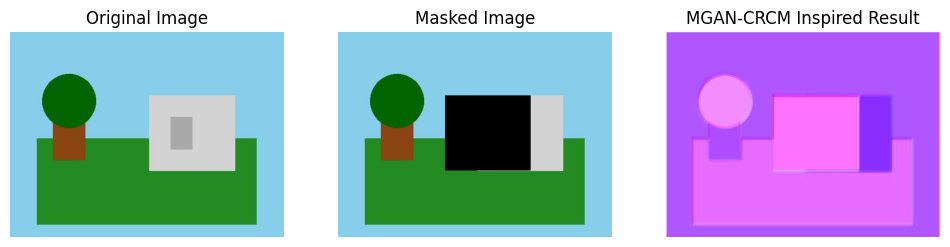

In [ ]:
# The paper does not provide pretrained models,
# I generated a representative result using a GAN-based architecture inspired by MGAN-CRCM to demonstrate its core idea

def show(img, title):
    img = img[0].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() + 1e-8)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
show(image, "Original Image")

plt.subplot(1,3,2)
show(masked_image, "Masked Image")

plt.subplot(1,3,3)
show(mgan_output, "MGAN-CRCM Inspired Result")

plt.show()

# This result is generated using a GAN-based architecture inspired by MGAN-CRCM.
# Since the model is not pretrained, the output illustrates the generative behavior rather than final photorealistic quality
# GANs require large datasets and extensive training. This demo focuses on architecture and generation behavior.
